<a href="https://colab.research.google.com/github/Sebas-Atehortua/Integracion-de-Datos-y-Prospectiva/blob/main/Integraci%C3%B3n_Credibilidad_FINTECH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integración de Datos y Credibilidad – Caso FINTECH**

El presente modelo tiene como objetivo integrar información interna y externa sobre eventos de fallos tecnológicos en una FINTECH, con el fin de obtener una estimación más robusta y estadísticamente consistente de la Distribución Agregada de Pérdidas (LDA).

Dado que la información interna puede ser limitada en tamaño muestral y la información externa puede diferir en estructura de riesgo, se emplea la Teoría de la Credibilidad para determinar el ***grado de afinidad o compatibilidad*** entre ambas bases de datos y establecer una ponderación óptima en el proceso de integración.

Para ello, el análisis se estructura en conocer las siguientes variables:

*   Frecuencia: Número de transacciones fallidas por día
*   Severidad: Impacto económico que se asocia a cada evento
*   Distribución Agregada de Pérdidas (LDA) como el producto entre ambas, sin embargo, se emplea el Método de Montecarlo para simular múltiples escenarios posibles de pérdida diaria y así caracterizar la distribución completa del riesgo.

Es así que, para el enriquecimiento de los datos se utilizarán como referencia el Método de Montecarlo (Ruleta Cargada - Muestreo Aleatorio) y la Teoría de la Credibilidad, la cual muestra cuál es la afinidad que poseen datos externos (AdmonEjecProcesos) frente a los datos que poseo internamente (Fallos_Tecnológicos).

0. Se cargan las librerías de trabajo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Configuración de estilo
sns.set_theme(style="whitegrid")

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Se montan los archivos de trabajo.

0      0.5374
1      4.7912
2      2.1345
3      6.4884
4      8.4735
        ...  
696    0.5747
697    4.3254
698    3.6280
699    1.0860
700    3.7288
Length: 701, dtype: float64
0      0.395144
1      0.148815
2      0.349362
3      0.107869
4      0.819804
         ...   
345    0.578173
346    0.108817
347    3.487451
348    0.048614
349    0.560543
Length: 350, dtype: float64


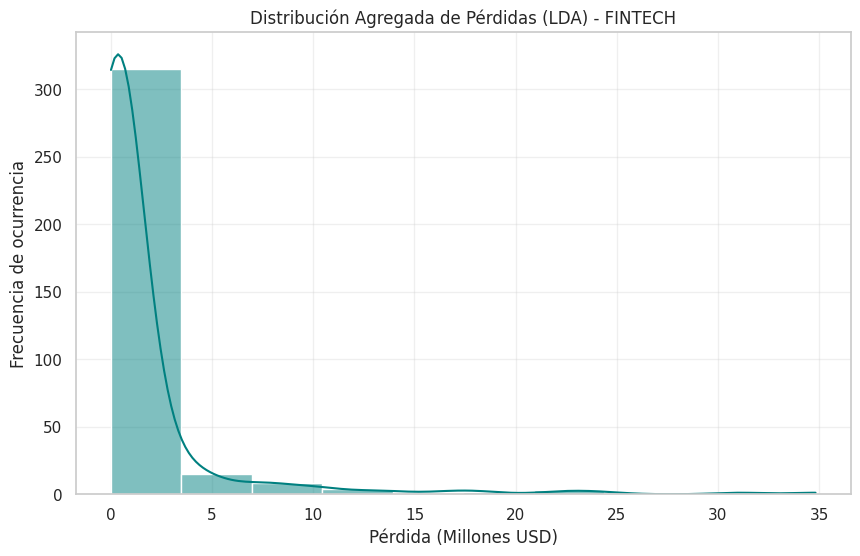

In [5]:
# Cargar base interna (Fallos Tecnológicos)
bd_int = pd.read_excel('/content/drive/MyDrive/Proyecto FINTECH_2/1. FallasTecnológicas.xlsx')
bd_int.head(10)

# Determinamos la frecuencia y severidad de la base interna

Freq=bd_int.iloc[:,3]
Sev=bd_int.iloc[:,4]
LDA_interna=Freq*Sev
print(LDA_interna)

# Cargar base externa (AdmonEjecProcesos)
bd_ext = pd.read_excel('/content/drive/MyDrive/Proyecto FINTECH_2/2. AdmonEjecProcesos.xlsx')
bd_ext.head(10)

# Determinamos la frecuencia y severidad de la base interna

Freq_ext=bd_ext.iloc[:,3]
Sev_ext=bd_ext.iloc[:,4]
LDA_externa=Freq_ext*Sev_ext
print(LDA_externa)

# Visualizamos inicialmente los datos usando la librería Seaborn

plt.figure(figsize=(10, 6))
sns.histplot(LDA_externa, bins=10, kde=True, color='teal')
plt.title("Distribución Agregada de Pérdidas (LDA) - FINTECH")
plt.xlabel("Pérdida (Millones USD)")
plt.ylabel("Frecuencia de ocurrencia")
plt.grid(True, alpha=0.3)
plt.show()

2. Se crea el método de caracterización de las variables

In [6]:
def caracterizacion(X, nombre):

    print(f"\n===== {nombre} =====")

    media = round(np.mean(X), 2)
    varianza = round(np.var(X), 2)
    desviacion = round(np.std(X), 2)
    asimetria = round(skew(X), 2)
    curtosis = round(kurtosis(X), 2)

    print("Media:", media)
    print("Varianza:", varianza)
    print("Desviación:", desviacion)
    print("Asimetría:", asimetria)
    print("Curtosis:", curtosis)

    plt.figure(figsize=(6,4))
    sns.histplot(X, bins=15, kde=True)
    plt.title(f"Distribución de la {nombre}")
    plt.xlabel("Pérdida (Millones USD)")
    plt.ylabel("Frecuencia de ocurrencia")
    plt.grid()
    plt.show()

    return media, varianza, desviacion, asimetria, curtosis

**2.1.** Caracterizamos las variables.
(Se determinan las medidas de frecuencia central, asimetría y curtosis para las bases de datos)


===== LDA Interna =====
Media: 9.45
Varianza: 187.89
Desviación: 13.71
Asimetría: 3.35
Curtosis: 14.17


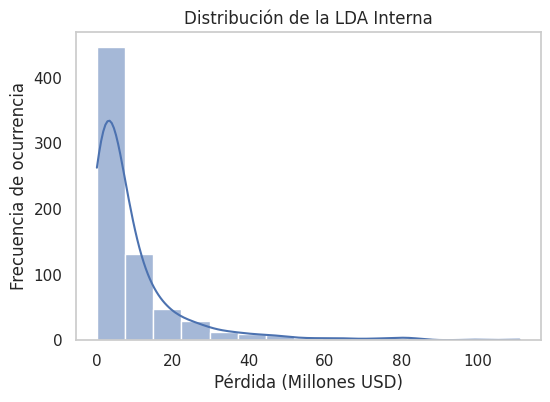


===== LDA Externa =====
Media: 1.47
Varianza: 16.07
Desviación: 4.01
Asimetría: 5.06
Curtosis: 29.64


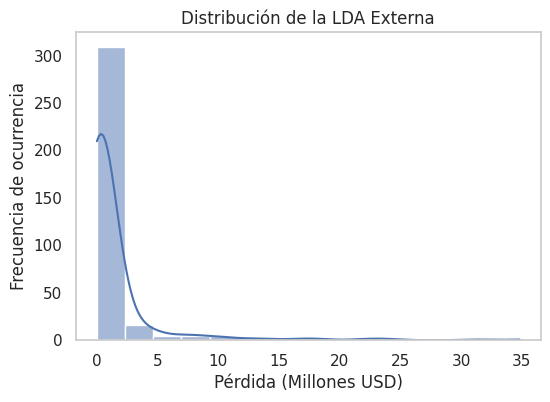

In [7]:
uo, varo, sigmao, Caso, Kuo = caracterizacion(LDA_interna, "LDA Interna")
ue, vare, sigmae, Case, Kue = caracterizacion(LDA_externa, "LDA Externa")

3. Elaboramos la Teoría de la Credibilidad

In [9]:

# 0. Tamaños de las muestras
NDo = len(LDA_interna)      # Base interna
NDe = len(LDA_externa)     # Base externa

# 1. Media hipotética combinada
uhat = (NDo*uo + NDe*ue) / (NDo + NDe)

# 2. EPV (Expected Process Variance)
EPV = (NDo*sigmao**2 + NDe*sigmae**2) / (NDo + NDe)

# 3. VHM (Variance of Hypothetical Means)
VHM = ((NDo*uo**2 + NDe*ue**2) / (NDo + NDe)) - uhat**2

# 4. Parámetro K
K = EPV / VHM

# 5. Factor de credibilidad interna (Bühlmann)
Z = NDo / (NDo + K)

# 6. Credibilidad externa
Z_ext = 1 - Z

print("K:", round(K,4))
print("Credibilidad Interna (Z):", round(Z,4))
print("Credibilidad Externa:", round(Z_ext,4))

K: 9.2421
Credibilidad Interna (Z): 0.987
Credibilidad Externa: 0.013


**3.1. Conclusión de la teoría de credibilidad**

La aplicación del modelo de credibilidad de Bühlmann arroja un factor de credibilidad interna de 98.7%, indicando que la experiencia histórica propia de la FINTECH es estadísticamente robusta y suficiente para estimar el nivel esperado de pérdidas operacionales.

En consecuencia, la información externa tiene una influencia marginal (1.3%), por lo que el capital económico estará determinado principalmente por la dinámica interna de pérdidas.

3.2. Se grafican las LDA sobrepuestas para observar las diferencias de distribución debido al tamaño de la muestra

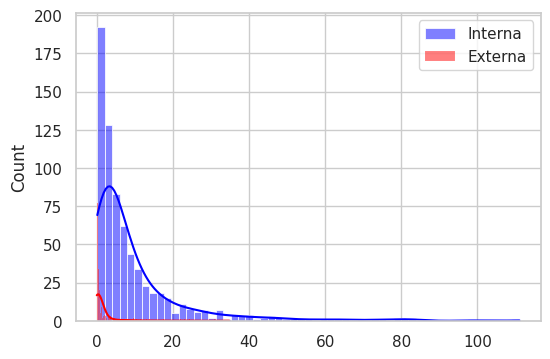

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(LDA_interna, color='blue', label='Interna', kde=True)
sns.histplot(LDA_externa, color='red', label='Externa', kde=True)
plt.legend()
plt.show()

**Análisis**: El análisis gráfico evidencia una fuerte concentración de la base externa en niveles bajos de pérdida, mientras que la base interna presenta mayor dispersión y eventos extremos significativos. La superposición parcial en la región de bajas pérdidas y el tamaño muestral interno justifican el alto factor de credibilidad (Z=0.987), validando la predominancia de la experiencia interna en la estimación del riesgo agregado.

**4. Simulación Monte Carlo e Inferencia del Capital Económico**

Una vez estimados los parámetros estadísticos de las distribuciones interna y externa, y determinada la ponderación óptima mediante la Teoría de la Credibilidad de Bühlmann, se procede a simular la Distribución Agregada de Pérdidas (LDA) integrada.

Dado que el factor de credibilidad interna obtenido fue Z ≈ 0.987, la distribución final estará dominada principalmente por la experiencia histórica propia de la FINTECH, incorporando de manera marginal la información externa.

Utilizaremos el histograma de las transacciones fallidas para generar una distribución de probabilidad y simular escenarios futuros de pérdida mediante el método de Montecarlo o ruleta cargada.

A partir de la distribución simulada se estimarán:

- Pérdida Esperada (EL)
- Stress Loss (VaR 99.9%)
- Pérdida No Esperada (UL)

Estas métricas permiten determinar el capital económico requerido para cubrir eventos extremos de riesgo operacional.

4.1. Elaboramos el modelo de Montecarlo

In [11]:
# Se genera una semilla de valor aleatorio para asegurar la reproducibilidad del modelo.
np.random.seed(40)

# Establecemos el número de simulaciones
n_sim = 10000

# Se genera la simulaciones para las LDA interna y externa:
sim_int = np.random.choice(LDA_interna, n_sim, replace=True); sim_ext = np.random.choice(LDA_externa, n_sim, replace=True)

LDA_MC = Z*sim_int + (1-Z)*sim_ext

EL = np.mean(LDA_MC)

SL_999 = np.percentile(LDA_MC, 99.9)

UL = SL_999 - EL

print("Pérdida Esperada (EL):", round(EL,2))
print("Stress Loss 99.9%:", round(SL_999,2))
print("Pérdida No Esperada (UL):", round(UL,2))



Pérdida Esperada (EL): 9.18
Stress Loss 99.9%: 109.64
Pérdida No Esperada (UL): 100.46


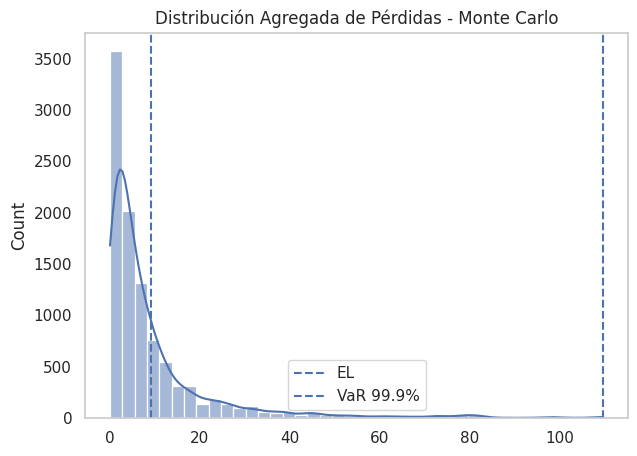

In [12]:
plt.figure(figsize=(7,5))
sns.histplot(LDA_MC, bins=40, kde=True)

plt.axvline(EL, linestyle='--', label='EL')
plt.axvline(SL_999, linestyle='--', label='VaR 99.9%')

plt.legend()
plt.title("Distribución Agregada de Pérdidas - Monte Carlo")
plt.grid()
plt.show()

**5. Conclusión del Modelo**

La integración de datos mediante la Teoría de la Credibilidad permitió determinar que la experiencia interna de la FINTECH posee un alto grado de robustez estadística (Z ≈ 98.7%), por lo que la estimación del riesgo agregado está dominada principalmente por la información histórica propia.

La simulación Monte Carlo evidenció una distribución asimétrica con cola derecha pronunciada, consistente con la naturaleza del riesgo operacional tecnológico.

El percentil 99.9% representa el escenario de pérdida catastrófica bajo condiciones extremas, y la diferencia respecto a la pérdida esperada constituye el capital económico requerido para absorber shocks severos.

En consecuencia, el modelo desarrollado permite estimar de forma estructurada y cuantitativamente consistente el requerimiento de capital asociado a fallos tecnológicos en la FINTECH, integrando información interna y externa bajo un marco estadístico formal.